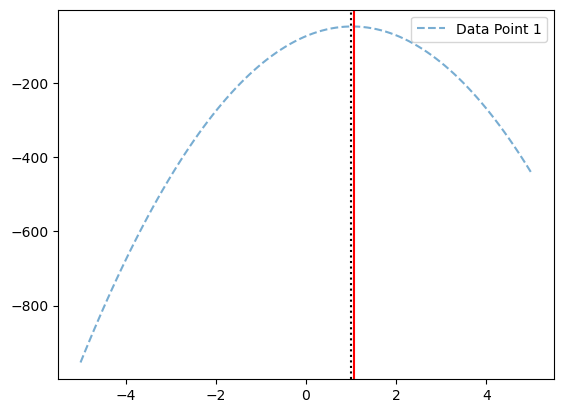

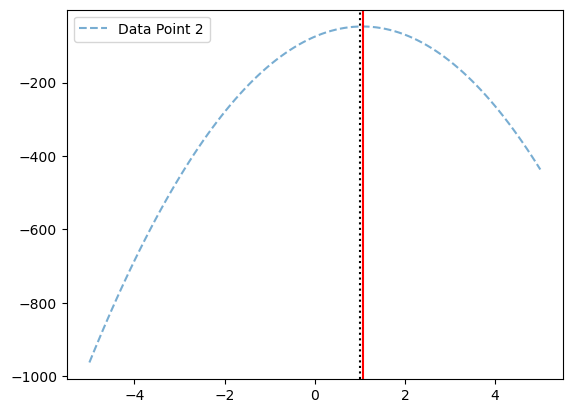

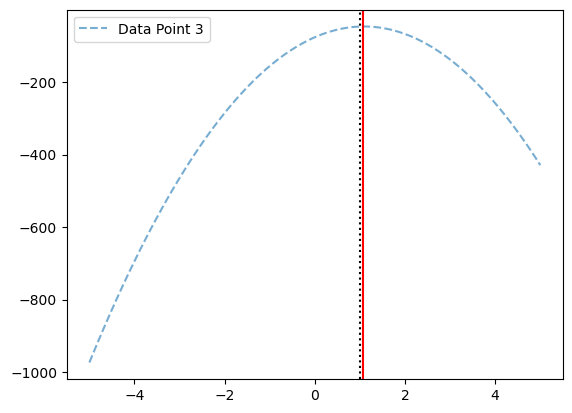

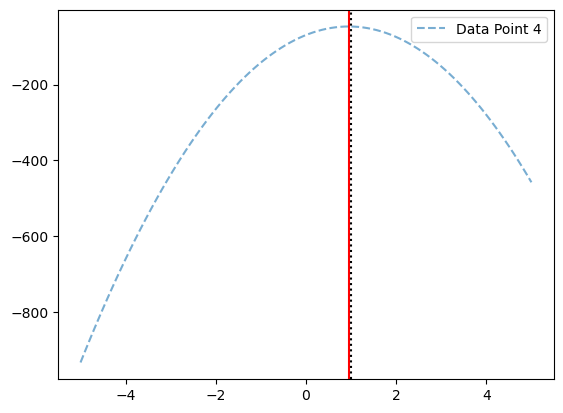

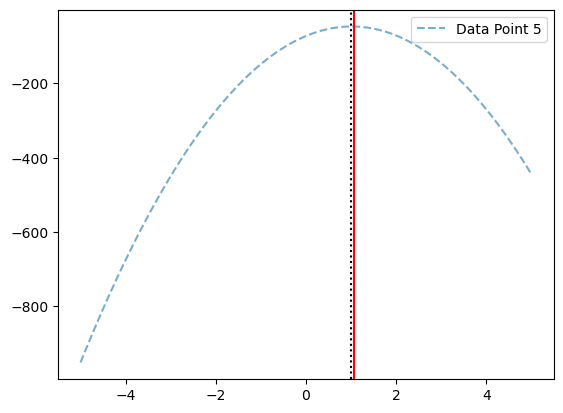

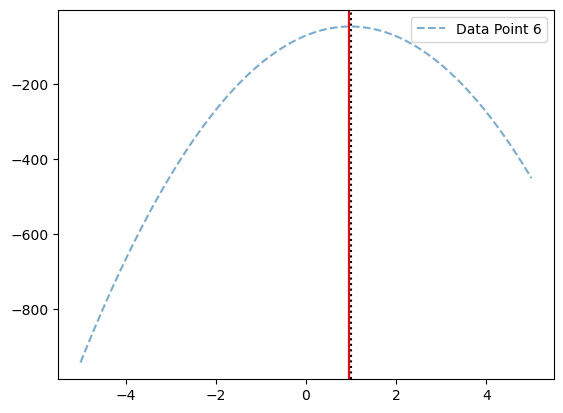

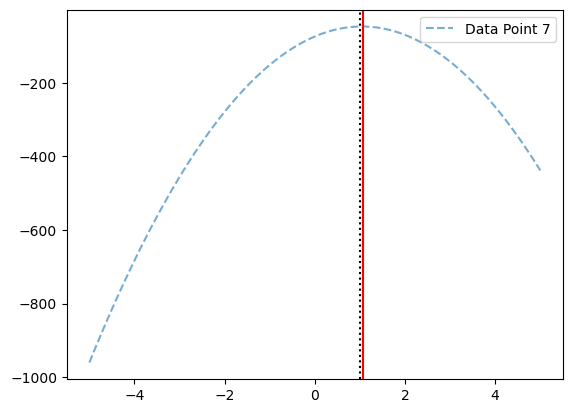

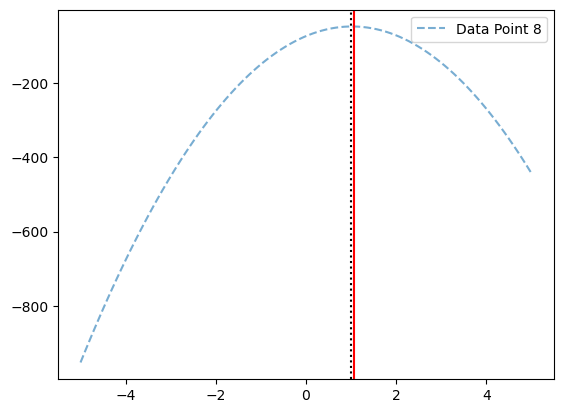

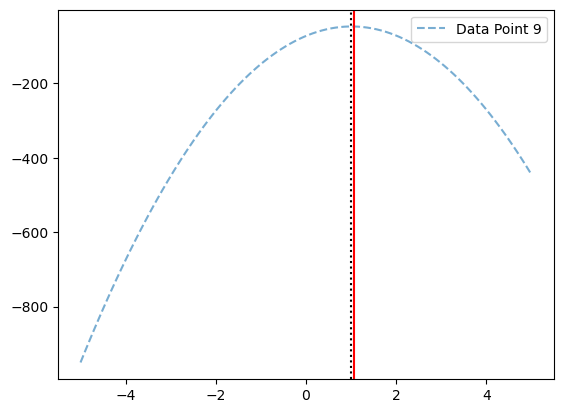

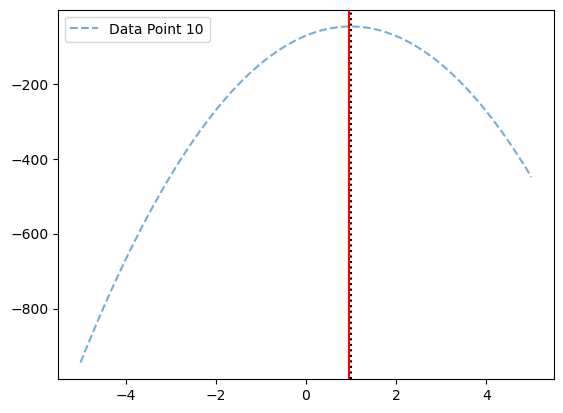

In [109]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

N = 10

all_max_mu = []

true_mu = 1
sigma = 0.2


total_lnL = np.zeros(100)

#plot individual likelihoods and product likelihood
for i in range(N):   
    
    # generate fake measurements from a gaussian
    gaussian_data = norm.rvs(true_mu, scale=sigma, size=50)

    # scan across 100 possible mu values from -5 to 5
    mu_proposed = np.linspace(-5,5,100)
    # compute the lnL fro each possible mu
    lnL_scan = []
    for mu in mu_proposed:
        # I am taking the logarithm of the gaussian
        lnL_temp = norm.logpdf(gaussian_data, loc=mu) # loc is the median of the gaussian
        lnL_temp = np.sum(lnL_temp) 
        lnL_scan.append( lnL_temp )
    
    total_lnL += lnL_scan
    
    # convert to numpy array
    lnL_scan = np.array(lnL_scan)

    plt.plot(mu_proposed, lnL_scan, linestyle='--', alpha=0.6, label=f'Data Point {i+1}''')
    plt.legend()
    
    # mu_proposed that maximizes the lnL
    findmax = mu_proposed[np.argmax(lnL_scan)]
    all_max_mu.append(findmax)
    
    plt.axvline(findmax,c='red')

    plt.axvline(1,c='black',ls='dotted')
    plt.show()


Maximum likelihood solution: 1.0606060606060606
MLE estimator: 1.03030303030303


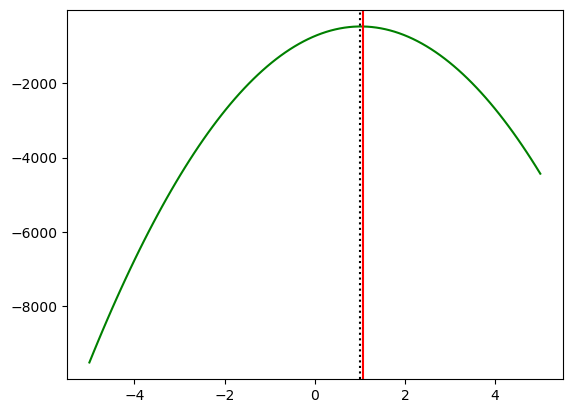

In [110]:
total_lnL = np.array(total_lnL)

# value that maximizes the product of the likelihoods
max_total = mu_proposed[np.argmax(total_lnL)]

plt.plot(mu_proposed, total_lnL, color='green')
plt.axvline(max_total,c='red')
print('Maximum likelihood solution:',max_total)

plt.axvline(1,c='black',ls='dotted')

# MLE estimator found for a gaussian distribution
mle_estimator = np.sum(all_max_mu)/len(all_max_mu)
print('MLE estimator:',mle_estimator)


In [114]:
# check the fisher matrix error

# second order differentiation
dx = mu_proposed[1] - mu_proposed[0]
first_deriv = np.diff(total_lnL) / dx
second_deriv = -1 * np.diff(first_deriv) / dx
error = np.sqrt(1 / second_deriv[np.argmax(total_lnL)])
print('Likelihood error:', error)

# Fisher matrix error
fisher_error = sigma / np.sqrt(N)
print('Fisher matrix error estimat:', fisher_error)

Likelihood error: 0.04472135954999639
Fisher matrix error estimat: 0.06324555320336758


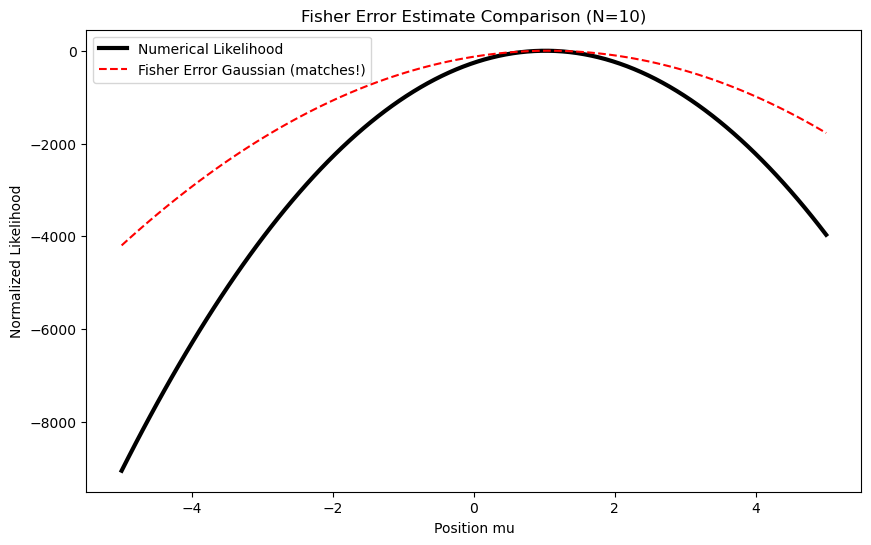

Numerical Fisher Error: 0.044721
Analytic Fisher Error (sigma/sqrt(N)): 0.063246


In [124]:
# 4. Plotting and Comparison
plt.figure(figsize=(10, 6))

# The actual numerical likelihood (exponentiated and normalized for view)
likelihood_numeric = (total_lnL - np.max(total_lnL))
plt.plot(mu_proposed, likelihood_numeric, color='black', lw=3, label='Numerical Likelihood')

# The Fisher-based Gaussian
# We use the numeric MLE and the Fisher Sigma to see if the shapes match
fisher_gaussian = norm.logpdf(mu_proposed, loc=mu_proposed[np.argmax(total_lnL)], scale=error)
fisher_gaussian /= np.max(fisher_gaussian) # Rescale to match numerical height
plt.plot(mu_proposed, fisher_gaussian, 'r--', label='Fisher Error Gaussian (matches!)')

plt.title(f"Fisher Error Estimate Comparison (N={N})")
plt.xlabel("Position mu")
plt.ylabel("Normalized Likelihood")
plt.legend()

plt.show()

print(f"Numerical Fisher Error: {error:.6f}")
print(f"Analytic Fisher Error (sigma/sqrt(N)): {fisher_error:.6f}")